In [2]:
# ============================================================
# 1. Import libraries
# ============================================================

# pandas is used for data loading, cleaning, filtering and aggregation.
import pandas as pd

# numpy is useful for numerical operations and handling missing/infinite values.
import numpy as np

# matplotlib is the core visualization library used in this notebook.
import matplotlib.pyplot as plt

# matplotlib.ticker helps us format axis labels in a readable way.
from matplotlib.ticker import FuncFormatter

# pathlib helps us write file paths that work across operating systems.
from pathlib import Path


# Optional: make pandas display more columns when we inspect the dataset.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# A small global setting: larger default figure size improves readability in class.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False 


In [3]:
# ============================================================
# 2. Load the dataset
# ============================================================

# Load the dataset from the CSV file named "data/symbol_info_3-25.csv" into a pandas DataFrame.
df_raw = pd.read_csv("symbol_info_3-25.csv")

# Show the dataset shape: rows and columns.
print("Dataset shape:", df_raw.shape)

# Preview the first rows.
df_raw.head()

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [4]:
# ============================================================
# 3. Inspect columns and missing values
# ============================================================

# A real analyst should never start plotting before understanding the data.
# Here we inspect column names, data types and missing values.

summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100).round(2)
})

summary

,column,dtype,missing_values,missing_pct
0,symbol,object,0,0.0
1,company_name,object,0,0.0
2,sector,object,2,0.2
3,industry,object,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


In [5]:
# ============================================================
# 4. Clean the investment universe
# ============================================================

# Start from the raw dataset (independent copy)
cleaned_df=df_raw.copy()


# Keep active operating companies only.
# is_etf == 0 removes ETFs.
# is_fund == 0 removes funds.
# is_actively_trading == 1 keeps securities that are currently trading.

cleaned_df= cleaned_df[
    (cleaned_df['is_actively_trading']==True) & 
    (cleaned_df['is_fund']==False) &
    (cleaned_df['is_etf']==False)
].copy()

# Filter to the Utilities sector (Student ID ending in 0 → Utilities).
utilities_df = cleaned_df[cleaned_df['sector'] == 'Utilities'].copy()

# Transparency check: show how many rows survived each filtering stage.
print(f"Raw: {len(df_raw):,} → Active companies: {len(cleaned_df):,} → Utilities: {len(utilities_df):,}")


# ── Unit conversions ──────────────────────────────────────────────────────────
# Converting large dollar values to billions makes chart axes readable.
utilities_df["market_cap_b"]       = utilities_df["market_cap"]       / 1e9
utilities_df["enterprise_value_b"] = utilities_df["enterprise_value"]  / 1e9
utilities_df["revenue_b"]          = utilities_df["total_revenue"]     / 1e9
utilities_df["net_income_b"]       = utilities_df["net_income"]        / 1e9
utilities_df["free_cashflow_b"]    = utilities_df["free_cashflow"]     / 1e9

# Converting decimal ratios to percentages for intuitive chart labels.
utilities_df["profit_margin_pct"]    = utilities_df["profit_margins"]    * 100
utilities_df["revenue_growth_pct"]   = utilities_df["revenue_growth"]    * 100
utilities_df["earnings_growth_pct"]  = utilities_df["earnings_growth"]   * 100
utilities_df["return_on_assets_pct"] = utilities_df["return_on_assets"]  * 100
utilities_df["return_on_equity_pct"] = utilities_df["return_on_equity"]  * 100

# dividend_yield is already in percentage-like units (e.g. 0.46 = 0.46%).
utilities_df["dividend_yield_pct"] = utilities_df["dividend_yield"]

# Replace infinite values (can arise from division in source data) with NaN.
utilities_df = utilities_df.replace([np.inf, -np.inf], np.nan)

print("Cleaned Utilities universe:", utilities_df.shape)
utilities_df[["symbol", "company_name", "sector", "market_cap_b", "revenue_b", "profit_margin_pct", "beta"]].head()

Raw: 1,000 → Active companies: 999 → Utilities: 42
Cleaned Utilities universe: (42, 49)


,symbol,company_name,sector,market_cap_b,revenue_b,profit_margin_pct,beta
73,NEE,"NextEra Energy, Inc.",Utilities,146.357273,24.753000,28.061000,0.574
117,SO,Southern Company (The),Utilities,98.679357,26.724000,16.468000,0.446
123,DUK,Duke Energy Corporation (Holdin,Utilities,93.366895,29.934000,15.113001,0.465
124,GEV,GE Vernova Inc.,Utilities,92.931711,34.935001,4.443000,0.000
172,CEG,Constellation Energy Corporatio,Utilities,69.705212,23.567999,15.907000,0.884


In [6]:
# ============================================================
# 5. Helper functions for cleaner charts
# ============================================================

# Reusable axis formatter: display numbers in billions (e.g. "25B").
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Reusable axis formatter: display percentages without decimals (e.g. "12%").
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Remove top and right chart borders for a cleaner report-style look.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Annotate each bar in a horizontal bar chart with its value.
# Handles both positive and negative values correctly.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        # Positive bars: label to the right; negative bars: label to the left.
        ha = 'left' if width >= 0 else 'right'
        offset = '  ' if width >= 0 else '  '
        ax.text(width, y, offset + fmt.format(width),
                va='center', ha=ha, fontsize=9)

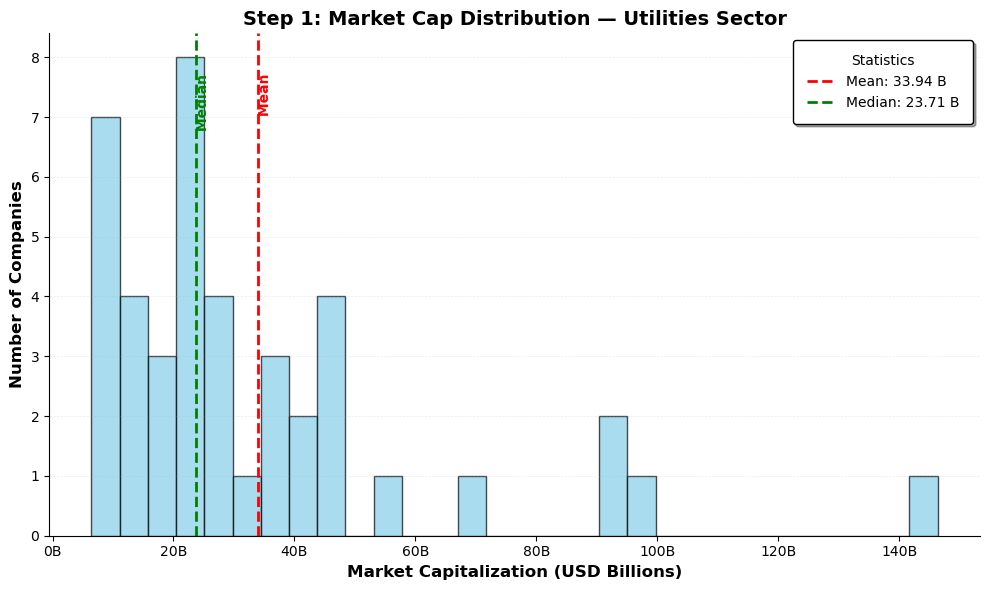

Mean market cap : 33.94 B
Median market cap: 23.71 B
Skewness         : 2.10  (positive → right-skewed, mean pulled up by mega-caps)


In [7]:
# ==============================================================================
# Step 1 — Market Capitalization Distribution
# ==============================================================================

# 1. Extract market cap values, dropping NaN to avoid histogram errors.
market_cap = utilities_df['market_cap_b'].dropna()

# 2. Compute central tendency metrics.
mean_val   = market_cap.mean()
median_val = market_cap.median()

# 3. Build the figure.
fig, ax = plt.subplots(figsize=(10, 6))

# Generate histogram with 30 bins for sufficient granularity.
ax.hist(market_cap, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# 4. Draw and annotate vertical lines for mean and median.
#    FIX: ax.get_xaxis_transform() anchors y in axis-fraction space (0–1),
#    so the labels always appear near the top regardless of the y-scale.
line_specs = {
    'Mean':   (mean_val,   'red'),
    'Median': (median_val, 'green'),
}
for label_name, (value, color) in line_specs.items():
    ax.axvline(value, color=color, linestyle='dashed', linewidth=2,
               label=f"{label_name}: {value:.2f} B")
    ax.text(
        value, 0.92,
        f" {label_name}",
        color=color, rotation=90, va='top', fontweight='bold',
        transform=ax.get_xaxis_transform()   # y is now in [0,1] axis fraction
    )

# 5. Formatting.
ax.set_title('Step 1: Market Cap Distribution — Utilities Sector',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Market Capitalization (USD Billions)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Companies',                 fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True,
          title='Statistics', borderpad=1, edgecolor='black')
ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5)
clean_spines(ax)

plt.tight_layout()
plt.show()

print(f"Mean market cap : {mean_val:.2f} B")
print(f"Median market cap: {median_val:.2f} B")
print(f"Skewness         : {market_cap.skew():.2f}  (positive → right-skewed, "
      f"mean pulled up by mega-caps)")

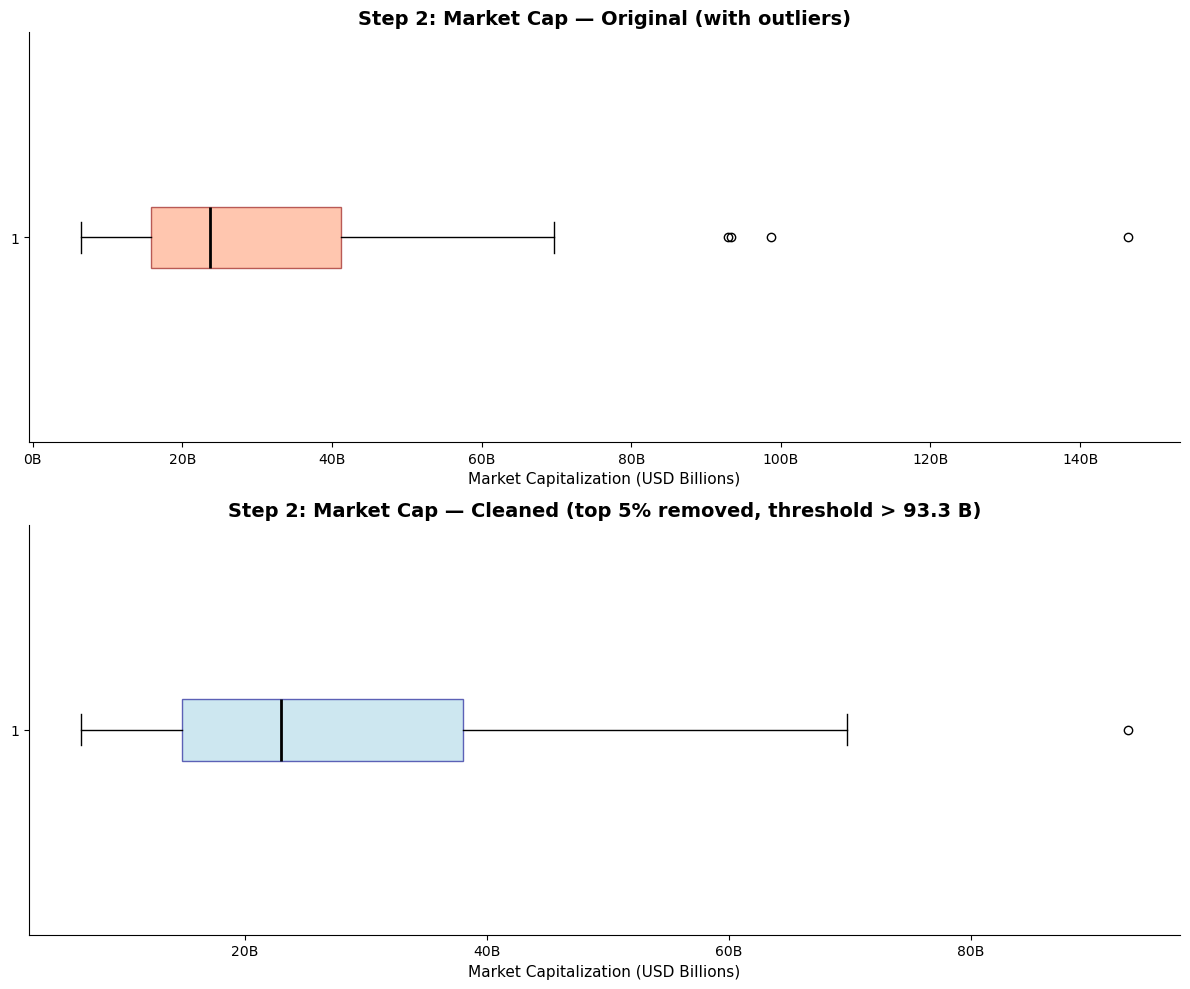

Data Cleaning Summary
  Total companies in sector : 42
  Threshold (95th pct)      : 93.35 B
  Outliers removed          : 3
  Final dataset size        : 39

Dataset used from this point forward: utilities_cleaned


In [22]:
# ==============================================================================
# Step 2 — Outlier Detection and Removal
# ==============================================================================

# CHOICE OF METHOD: 95th percentile vs IQR
# ─────────────────────────────────────────
# The IQR rule (Q3 + 1.5*IQR) is designed for roughly symmetric distributions.
# Market cap is strongly right-skewed (skewness > 3): applying IQR would flag
# perfectly valid mid-cap companies as outliers.
# The 95th-percentile cut removes only the top 5 % of the size distribution
# (the mega-caps such as NextEra) that distort chart scales without adding
# information about the typical sector structure.

# FIX: compute threshold directly on the DataFrame column (not on a dropna()
# series) to avoid any index-misalignment when building the boolean mask.
threshold = utilities_df['market_cap_b'].quantile(0.95)

utilities_cleaned = utilities_df[
    utilities_df['market_cap_b'].fillna(0) <= threshold
].copy()

# ── Comparative boxplots (before vs after) ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Before cleaning
ax1.boxplot(
    utilities_df['market_cap_b'].dropna(), vert=False, patch_artist=True,
    boxprops=dict(facecolor='lightsalmon', color='darkred', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
ax1.set_title('Step 2: Market Cap — Original (with outliers)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Market Capitalization (USD Billions)', fontsize=11)
ax1.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax1)

# After cleaning
ax2.boxplot(
    utilities_cleaned['market_cap_b'].dropna(), vert=False, patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='darkblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
ax2.set_title(f'Step 2: Market Cap — Cleaned (top 5% removed, threshold > {threshold:.1f} B)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Market Capitalization (USD Billions)', fontsize=11)
ax2.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax2)

plt.tight_layout()
plt.show()

# Cleaning summary
removed_count = len(utilities_df) - len(utilities_cleaned)
print(f"Data Cleaning Summary")
print(f"  Total companies in sector : {len(utilities_df)}")
print(f"  Threshold (95th pct)      : {threshold:.2f} B")
print(f"  Outliers removed          : {removed_count}")
print(f"  Final dataset size        : {len(utilities_cleaned)}")
print()
print("Dataset used from this point forward: utilities_cleaned")

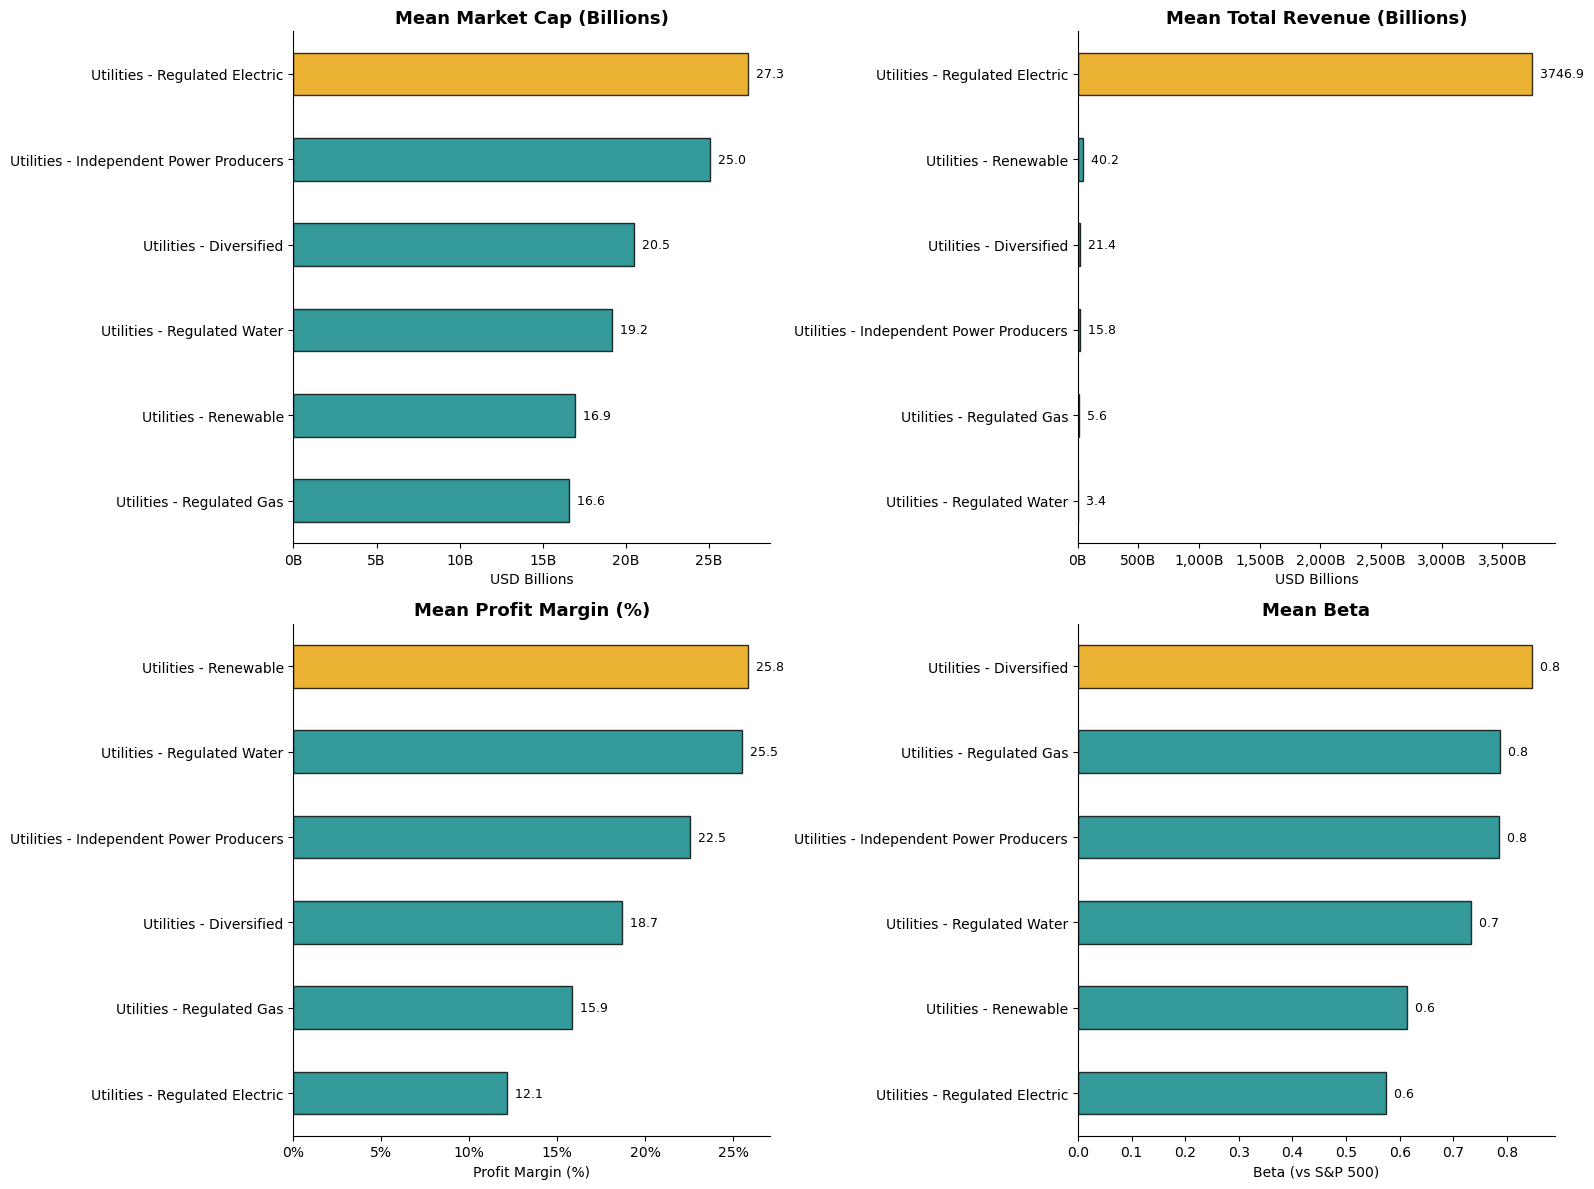

In [20]:
 # ==============================================================================
# Step 3 — Industry Comparison: Four Metrics
# ==============================================================================

# Metric columns and their display titles.
metrics = ['market_cap_b', 'revenue_b', 'profit_margin_pct', 'beta']
titles  = [
    'Mean Market Cap (Billions)',
    'Mean Total Revenue (Billions)',
    'Mean Profit Margin (%)',
    'Mean Beta'
]

# Axis labels per metric — beta gets an explicit label instead of 'Mean Value'.
xlabel_map = {
    'market_cap_b':     'USD Billions',
    'revenue_b':        'USD Billions',
    'profit_margin_pct':'Profit Margin (%)',
    'beta':             'Beta (vs S&P 500)'
}

# Color palette: Teal (#008080) for standard bars, Orange (#E69F00, Wong palette)
# for the leader bar. Both are distinguishable by people with colour-vision deficiency.
color_normal = '#008080'
color_max    = '#E69F00'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Aggregate: mean per industry, sorted ascending so the leader is on top.
    industry_stats = utilities_cleaned.groupby('industry')[metric].mean().sort_values()

    # Highlight the leading industry with a different colour.
    colors = [color_normal] * (len(industry_stats) - 1) + [color_max]

    industry_stats.plot(kind='barh', ax=axes[i], color=colors,
                        edgecolor='black', alpha=0.8)

    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel(xlabel_map[metric], fontsize=10)

    # Apply the correct unit formatter for each metric.
    if 'market_cap' in metric or 'revenue' in metric:
        axes[i].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
    elif 'profit_margin' in metric:
        axes[i].xaxis.set_major_formatter(FuncFormatter(pct_formatter))
    # Beta has no special formatter — raw numeric values are clear enough.

    annotate_hbar(axes[i])
    clean_spines(axes[i])

plt.tight_layout()
plt.show()

/var/folders/gr/b1rcy3m56k715qdxrj1xjr400000gn/T/ipykernel_1900/2168174120.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/var/folders/gr/b1rcy3m56k715qdxrj1xjr400000gn/T/ipykernel_1900/2168174120.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/var/folders/gr/b1rcy3m56k715qdxrj1xjr400000gn/T/ipykernel_1900/2168174120.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/var/folders/gr/b1rcy3m56k715qdxrj1xjr400000gn/T/ipykernel_1900/2168174120.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labe

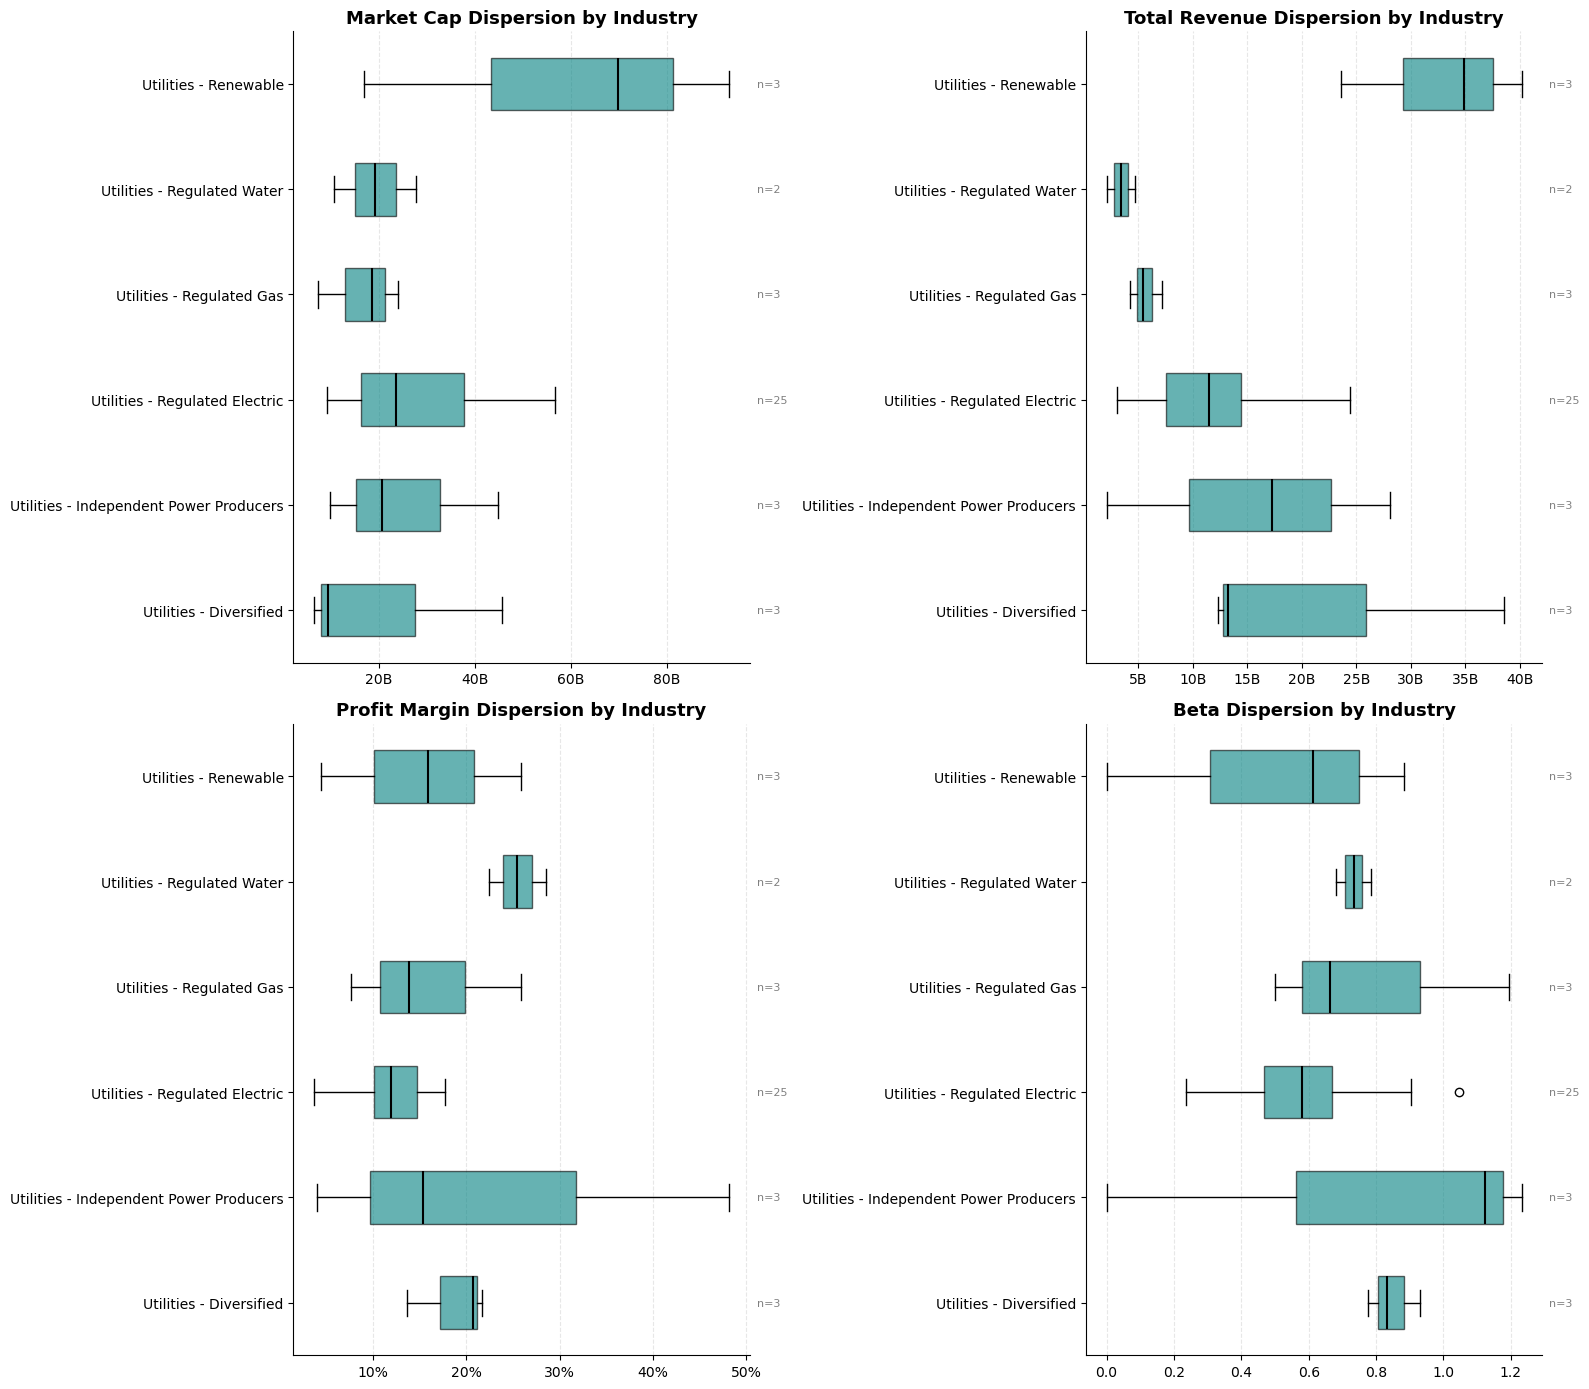

In [31]:
# ==============================================================================
# Step 4 — Industry Dispersion (Boxplot Matrix)
# ==============================================================================

metrics = ['market_cap_b', 'revenue_b', 'profit_margin_pct', 'beta']
titles  = [
    'Market Cap Dispersion by Industry',
    'Total Revenue Dispersion by Industry',
    'Profit Margin Dispersion by Industry',
    'Beta Dispersion by Industry'
]

# Sort industries alphabetically so the Y-axis order is consistent across all
# four subplots, making visual comparison easier.
industries = sorted(utilities_cleaned['industry'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    data_to_plot = [
        utilities_cleaned[utilities_cleaned['industry'] == ind][metric].dropna()
        for ind in industries
    ]
    # showfliers=False only for Revenue: the scale outlier collapses the axis
    # to 80,000B, making all boxplots unreadable. For the other 3 subplots,
    # the outliers remain visible because they provide meaningful information.
    # The utilities_cleaned dataset is NOT modified — from Step 5 onward
    # we continue to use the 95th percentile market_cap cleaning from Step 2.
    show_fliers = (metric != 'revenue_b')

    bp = axes[i].boxplot(
        data_to_plot, labels=industries, vert=False, patch_artist=True,
        showfliers=show_fliers,
        medianprops=dict(color='black', linewidth=1.5)
    )
    # Teal fill at 60% opacity — colorblind-friendly and readable on white.
    for patch in bp['boxes']:
        patch.set_facecolor('#008080')
        patch.set_alpha(0.6)

    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)
    clean_spines(axes[i])

    if 'market_cap' in metric or 'revenue' in metric:
        axes[i].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
    elif 'profit_margin' in metric:
        axes[i].xaxis.set_major_formatter(FuncFormatter(pct_formatter))

    # Add n= counts alongside each boxplot to make sample sizes transparent.
    # This is important because IPP (n=3) and Regulated Electric (n=25) are
    # very different in size — a boxplot alone can mislead without this context.
    x_right = axes[i].get_xlim()[1]
    for j, series in enumerate(data_to_plot):
        axes[i].text(
            x_right, j + 1, f'  n={len(series)}',
            va='center', fontsize=8, color='gray'
        )

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# Step 5 — Filter: selected and excluded industries
# ==============================================================================

# FIX: define all variables in a single cell to avoid silent double-assignment
# of focus_df across multiple cells.

selected_industries = [
    'Utilities - Regulated Electric',
    'Utilities - Independent Power Producers',
    'Utilities - Regulated Water',
]

excluded_industries = [
    'Utilities - Renewable',
    'Utilities - Regulated Gas',
    'Utilities - Diversified',
]

focus_df    = utilities_cleaned[utilities_cleaned['industry'].isin(selected_industries)].copy()
excluded_df = utilities_cleaned[utilities_cleaned['industry'].isin(excluded_industries)].copy()

print("--- Focus Group ---")
print(f"Total companies: {len(focus_df)}")
print(focus_df['industry'].value_counts())
print()
print("--- Excluded Group ---")
print(f"Total companies: {len(excluded_df)}")
print(excluded_df['industry'].value_counts())

--- Focus Group ---
Total companies: 30
industry
Utilities - Regulated Electric             25
Utilities - Independent Power Producers     3
Utilities - Regulated Water                 2
Name: count, dtype: int64

--- Excluded Group ---
Total companies: 9
industry
Utilities - Renewable        3
Utilities - Diversified      3
Utilities - Regulated Gas    3
Name: count, dtype: int64


In [12]:
# ==============================================================================
# Step 5 — Granular industry investigation (selected + excluded)
# ==============================================================================

columns_to_show = ['symbol', 'company_name', 'market_cap_b', 'beta',
                   'profit_margins', 'debt_to_equity']
numeric_cols = ['market_cap_b', 'beta', 'profit_margins', 'debt_to_equity']

def show_industry_detail(df, industry_list, label):
    print(f"{'='*85}")
    print(f"  {label}")
    print(f"{'='*85}")
    for industry in industry_list:
        data = df[df['industry'] == industry].copy()
        if data.empty:
            print(f"  No data for {industry}")
            continue
        means = data[numeric_cols].mean()
        mean_row = means.to_frame().T
        mean_row['symbol']       = '-'
        mean_row['company_name'] = 'INDUSTRY AVERAGE'
        data = pd.concat([data, mean_row], ignore_index=True)
        print(f"\n{'─'*85}")
        print(f"  {industry.upper()}")
        print(f"{'─'*85}")
        display(data[columns_to_show].round(3))

show_industry_detail(focus_df,    selected_industries, "SELECTED INDUSTRIES")
print()
show_industry_detail(excluded_df, excluded_industries, "EXCLUDED INDUSTRIES")

  SELECTED INDUSTRIES

─────────────────────────────────────────────────────────────────────────────────────
  UTILITIES - REGULATED ELECTRIC
─────────────────────────────────────────────────────────────────────────────────────


,symbol,company_name,market_cap_b,beta,profit_margins,debt_to_equity
0,AEP,American Electric Power Company,56.683,0.492,0.150,170.451
1,D,"Dominion Energy, Inc.",46.846,0.584,0.147,141.186
2,EXC,Exelon Corporation,45.015,0.580,0.107,174.232
3,PEG,Public Service Enterprise Group,41.530,0.617,0.172,142.038
4,XEL,Xcel Energy Inc.,40.270,0.387,0.144,155.056
5,ED,"Consolidated Edison, Inc.",38.301,0.285,0.119,126.714
6,PCG,Pacific Gas & Electric Co.,37.730,1.045,0.101,191.911
7,ETR,Entergy Corporation,36.461,0.668,0.089,190.276
8,WEC,"WEC Energy Group, Inc.",34.257,0.443,0.178,159.108
9,DTE,DTE Energy Company,28.453,0.601,0.113,198.573



─────────────────────────────────────────────────────────────────────────────────────
  UTILITIES - INDEPENDENT POWER PRODUCERS
─────────────────────────────────────────────────────────────────────────────────────


,symbol,company_name,market_cap_b,beta,profit_margins,debt_to_equity
0,VST,Vistra Corp.,44.867,1.232,0.154,311.893
1,NRG,"NRG Energy, Inc.",20.501,1.123,0.040,443.664
2,TLN,Talen Energy Corporation,9.776,0.000,0.481,216.583
3,-,INDUSTRY AVERAGE,25.048,0.785,0.225,324.047



─────────────────────────────────────────────────────────────────────────────────────
  UTILITIES - REGULATED WATER
─────────────────────────────────────────────────────────────────────────────────────


...

,symbol,company_name,market_cap_b,beta,profit_margins,debt_to_equity
0,GEV,GE Vernova Inc.,92.932,0.000,0.044,10.016
1,CEG,Constellation Energy Corporatio,69.705,0.884,0.159,66.438
2,EBR,Centrais Electricas Brasileiras,16.938,0.614,0.258,64.130
3,-,INDUSTRY AVERAGE,59.858,0.499,0.154,46.861



─────────────────────────────────────────────────────────────────────────────────────
  UTILITIES - REGULATED GAS
─────────────────────────────────────────────────────────────────────────────────────


,symbol,company_name,market_cap_b,beta,profit_margins,debt_to_equity
0,ATO,Atmos Energy Corporation,23.939,0.664,0.259,66.587
1,NI,NiSource Inc,18.596,0.499,0.139,131.114
2,UGI,UGI Corporation,7.220,1.195,0.077,158.326
3,-,INDUSTRY AVERAGE,16.585,0.786,0.159,118.676



─────────────────────────────────────────────────────────────────────────────────────
  UTILITIES - DIVERSIFIED
─────────────────────────────────────────────────────────────────────────────────────


,symbol,company_name,market_cap_b,beta,profit_margins,debt_to_equity
0,SRE,DBA Sempra,45.602,0.776,0.217,98.735
1,AES,The AES Corporation,9.369,0.931,0.137,351.227
2,CIG,Comp En De Mn Cemig,6.440,0.833,0.207,51.856
3,-,INDUSTRY AVERAGE,20.470,0.847,0.187,167.273


## Step 5 — Focus Industry Selection and Analytical Rationale

Based on the distributional evidence from Steps 3 and 4, I selected three industries
using a **contrast-driven approach**: one high-risk merchant segment, one large regulated
benchmark, and one ultra-defensive water monopoly. Together they form a natural experiment
for observing how different business models respond to geopolitical shocks.

---

### Selected industries

#### Utilities — Independent Power Producers (IPP)

**Data insight:** This is the highest-risk segment in the dataset despite containing only
$n=3$ companies. The standard deviation of Beta (0.68) is the largest of any industry —
reflecting extreme heterogeneity: Talen Energy (Beta ≈ 0.000, a re-listing artefact),
Vistra (Beta > 1.1), and NRG (Beta > 1.1). The Debt-to-Equity ratio reaches 443%,
making earnings highly sensitive to input cost shocks. Included precisely because of this
risk profile — it is the "seismograph" industry for geopolitical events.

#### Utilities — Regulated Electric

**Data insight:** The statistical benchmark of the dataset ($n=25$). Companies cluster
tightly around a median Beta of 0.57 and profit margins of ~12%, reflecting the
predictability of rate-regulated revenues. Its large sample size provides the most
reliable industry-level signal in the universe.

#### Utilities — Regulated Water

**Data insight:** The defensive extreme ($n=2$: AWK and WTRG). Only two companies
populate this niche, suggesting a natural-monopoly or tight-oligopoly structure.
Profit margins range from 22% to 28% — the highest and most stable in the entire focus
group. Included as a "control group" theoretically isolated from fossil-fuel price shocks.

---

### Dropped industries

#### Utilities — Renewable

Dropped due to **transition-phase instability**. GE Vernova (GEV) has a 92B market cap
but Beta ≈ 0.000, signalling that its price history is too short to compute a meaningful
correlation with the S&P 500. Profit margins are significantly below the regulated
benchmarks. This sector is driven by CapEx cycles and policy risk, not operational
cash-flow stability — a different analytical story from the one we are telling.

#### Utilities — Regulated Gas

Dropped to avoid **statistical redundancy**. Mean Beta (0.78) and profit margins overlap
substantially with both Regulated Electric and Regulated Water. Keeping it would add
companies without adding a new risk/return dimension to the analysis.

#### Utilities — Diversified

Dropped due to **signal dilution** (the conglomerate effect). Companies such as Sempra
and AES cluster near the sector medians on every metric. Their multi-line business models
(mixing electric, gas, and infrastructure) mask the pure-play signals we need to isolate
the impact of a specific geopolitical event on a single operational structure.

In [13]:
# ==============================================================================
# Step 6 — Bubble Chart: Risk vs Profitability
# ==============================================================================
#
# ENCODING CHOICES AND WHAT EACH REVEALS
# ────────────────────────────────────────
# X-AXIS  → Beta (systemic risk):
#   Reveals how much each stock moves relative to the S&P 500.
#   High beta = amplified market swings; low beta = defensive behaviour.
#
# Y-AXIS  → Profit Margins (%):
#   Reveals operational efficiency — the company's ability to convert
#   revenue into net income under cost pressure.
#
# BUBBLE SIZE → Market Capitalisation (B):
#   Reveals the economic weight and market importance of each company.
#   Large bubbles dominate capital flows; small bubbles are niche players.
#
# BUBBLE COLOR → Industry (categorical):
#   FIX: Using industry instead of beta avoids redundant encoding
#   (beta was already on the X-axis). Color now adds a genuinely new
#   dimension, making it easy to see whether industries cluster together
#   or are dispersed across quadrants.
#
# QUADRANT LOGIC
# ──────────────
# Dividing lines are the medians of beta and profit_margins within the
# focus universe. This produces four quadrants:
#   Top-left    → Low Risk / High Profit   (defensive leaders)
#   Top-right   → High Risk / High Profit  (aggressive winners)
#   Bottom-left → Low Risk / Low Profit    (stable but thin margins)
#   Bottom-right→ High Risk / Low Profit   (most vulnerable)
# ==============================================================================

import plotly.express as px
import plotly.graph_objects as go

x_mid = focus_df['beta'].median()
y_mid = focus_df['profit_margins'].median()

fig = px.scatter(
    focus_df,
    x='beta',
    y='profit_margins',
    size='market_cap_b',
    color='industry',                         # FIX: categorical color, not beta
    hover_name='company_name',
    hover_data={
        'symbol':         True,
        'industry':       True,
        'beta':           ':.3f',
        'profit_margins': ':.2%',
        'market_cap_b':   ':.1f',
    },
    title='<b>Step 6: Risk vs Profitability — Utilities Focus Universe</b>',
    labels={
        'beta':           'Beta (Systemic Risk)',
        'profit_margins': 'Profit Margins',
        'market_cap_b':   'Market Cap (B)',
    },
    template='plotly_white',
    size_max=35,
)

# Quadrant dividing lines
fig.add_vline(x=x_mid, line_dash='dash', line_color='grey', opacity=0.4)
fig.add_hline(y=y_mid, line_dash='dash', line_color='grey', opacity=0.4)

# FIX: quadrant labels anchored in paper (axis-fraction) coordinates so they
# never overlap with data points regardless of the actual data range.
quadrant_labels = [
    (0.97, 0.97, 'right', 'top',    '<b>High Risk / High Profit</b>'),
    (0.03, 0.97, 'left',  'top',    '<b>Low Risk / High Profit</b>'),
    (0.97, 0.03, 'right', 'bottom', '<b>High Risk / Low Profit</b>'),
    (0.03, 0.03, 'left',  'bottom', '<b>Low Risk / Low Profit</b>'),
]
for xp, yp, xanchor, yanchor, text in quadrant_labels:
    fig.add_annotation(
        x=xp, y=yp, xref='paper', yref='paper',
        text=text, showarrow=False,
        xanchor=xanchor, yanchor=yanchor,
        font=dict(size=10, color='gray')
    )

fig.update_layout(
    xaxis=dict(title='<b>Beta (Systemic Risk)</b>',   gridcolor='rgba(0,0,0,0.05)'),
    yaxis=dict(title='<b>Profit Margins (%)</b>',
               tickformat='.0%',                      gridcolor='rgba(0,0,0,0.05)'),
    margin=dict(l=40, r=40, t=80, b=40),
    legend=dict(title='Industry'),
)

fig.show()

In [14]:
# ==============================================================================
# Step 7 — Zoom into the High Risk / High Profit Quadrant
# ==============================================================================
#
# QUADRANT CHOSEN: High Risk / High Profit (beta > median AND margins > median)
#
# RATIONALE: This is the most analytically interesting quadrant for studying the
# Hormuz crisis. Companies here have above-average systemic risk AND above-average
# profitability. Under a geopolitical energy shock, the key question is whether
# their high margins act as a buffer — or whether high beta amplifies the fall.
# This tension produces the clearest signal in the price chart.
#
# RANKING DIMENSION: Market capitalisation (largest first), so we focus on the
# companies that dominate capital flows in this quadrant.
# ==============================================================================

import yfinance as yf

x_mid = focus_df['beta'].median()
y_mid = focus_df['profit_margins'].median()

q7_df = focus_df[
    (focus_df['beta']           > x_mid) &
    (focus_df['profit_margins'] > y_mid)
].sort_values('market_cap_b', ascending=False)

selected_tickers_1 = q7_df['symbol'].head(10).tolist()
print(f"Step 7 quadrant: High Risk / High Profit")
print(f"Tickers selected (top 10 by market cap): {selected_tickers_1}")

# ── Price data: download, clean, normalise ────────────────────────────────────
print("\nDownloading 3-month price history...")
raw_data = yf.download(selected_tickers_1, period="3mo", interval="1d")['Close']

# FIX: remove days where ALL tickers have NaN (e.g. holidays with no data at all).
raw_data = raw_data.dropna(how='all')

# FIX: normalise each column by its own first valid price, not by row 0 blindly.
# This prevents a divide-by-NaN error when a ticker has no price on day 1.
first_valid = raw_data.apply(
    lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else 1
)
df_ts = raw_data / first_valid

# Equal-weighted quadrant average (used as a benchmark line).
df_ts['QUADRANT_AVG'] = df_ts[selected_tickers_1].mean(axis=1)

# ── Earnings annotations ──────────────────────────────────────────────────────
earnings_annotations = []
for ticker_symbol in selected_tickers_1:
    t = yf.Ticker(ticker_symbol)
    try:
        dates = t.earnings_dates
        if dates is not None:
            mask = (dates.index > df_ts.index.min()) & (dates.index < df_ts.index.max())
            for day in dates[mask].index:
                date_str = day.strftime('%Y-%m-%d')
                if date_str in df_ts.index.strftime('%Y-%m-%d'):
                    price_val = df_ts.loc[df_ts.index[df_ts.index.strftime('%Y-%m-%d') == date_str][0], ticker_symbol]
                    earnings_annotations.append(dict(
                        x=day, y=price_val,
                        text=f"{ticker_symbol} Q1 Report",
                        showarrow=True, arrowhead=2, ax=0, ay=-30,
                        font=dict(size=9, color="black"),
                        bgcolor="yellow", opacity=0.8
                    ))
    except Exception:
        continue

# ── Interactive chart ─────────────────────────────────────────────────────────
fig = go.Figure()

for ticker in selected_tickers_1:
    fig.add_trace(go.Scatter(
        x=df_ts.index, y=df_ts[ticker],
        name=ticker, mode='lines',
        line=dict(width=1.5), opacity=0.5
    ))

fig.add_trace(go.Scatter(
    x=df_ts.index, y=df_ts['QUADRANT_AVG'],
    name='<b>QUADRANT AVG</b>',
    line=dict(color='black', width=3, dash='dash')
))

# Phase highlights
fig.add_vrect(x0="2026-03-15", x1="2026-04-10",
              fillcolor="red", opacity=0.1, line_width=0,
              annotation_text="Geopolitical Shock", annotation_position="top left")
fig.add_vrect(x0="2026-04-30", x1="2026-05-15",
              fillcolor="orange", opacity=0.1, line_width=0,
              annotation_text="Q1 Earnings Impact", annotation_position="top right")

for ann in earnings_annotations:
    fig.add_annotation(ann)

fig.add_hline(y=1.0, line_dash="solid", line_color="black", opacity=0.3)

fig.update_layout(
    title="<b>Step 7 — High Risk / High Profit: Normalised Price Performance</b>"
          "<br><sup>Prices vs. Q1 Earnings under Suez/Hormuz Tensions (2026)</sup>",
    xaxis_title="Date",
    yaxis_title="Normalised Price (Base = 1.0 on first trading day)",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    margin=dict(l=50, r=160, t=100, b=50)
)

fig.show()

Step 7 quadrant: High Risk / High Profit
Tickers selected (top 10 by market cap): ['VST', 'PEG', 'AWK', 'EVRG', 'WTRG', 'OGE']



[*********************100%***********************]  6 of 6 completed


In [15]:
# ==============================================================================
# Step 7 — Geopolitical Audit (shared function for Steps 7 and 8)
# ==============================================================================
#
# FIX: the original notebook defined two nearly identical functions
# (perform_geopolitical_audit for Step 7, get_enhanced_analysis for Step 8).
# They have been merged into a single parametric function used by both steps.

pre_crisis   = "2026-01-01"
crisis_start = "2026-03-01"   # Onset of Hormuz Strait tensions
current_date = "2026-05-10"   # Analysis date

def geopolitical_audit(tickers, label=""):
    """
    Audits price resilience and YoY fundamental health for a list of tickers
    during the 2026 Strait of Hormuz crisis.

    Parameters
    ----------
    tickers : list[str]   Ticker symbols to analyse.
    label   : str         Optional heading printed above the output table.

    Returns
    -------
    pd.DataFrame  One row per ticker with shock, recovery, and fundamental data.
    """
    results = []

    for t_sym in tickers:
        t = yf.Ticker(t_sym)
        try:
            is_ = t.quarterly_financials
            bs  = t.quarterly_balance_sheet
            cf  = t.quarterly_cashflow

            def gv(df, names, idx):
                """Safely retrieve a row from a financial DataFrame."""
                for name in names:
                    if name in df.index:
                        return df.loc[name].iloc[idx]
                return np.nan

            # YoY comparison: Q1 2026 (idx 0) vs Q1 2025 (idx 4).
            ni_q1_26 = gv(is_, ['Net Income'], 0)
            ni_q1_25 = gv(is_, ['Net Income'], 4)
            ni_yoy   = ((ni_q1_26 - ni_q1_25) / abs(ni_q1_25)) * 100 if ni_q1_25 else np.nan

            fcf    = gv(cf, ['Free Cash Flow'], 0)
            debt   = gv(bs, ['Total Debt'], 0)
            equity = gv(bs, ['Stockholders Equity'], 0)
            de     = debt / equity if equity else np.nan

            history    = t.history(start=pre_crisis, end=current_date)
            price_pre  = history.loc[:crisis_start]['Close'].mean()
            price_min  = history.loc[crisis_start:]['Close'].min()
            price_now  = history['Close'].iloc[-1]

            shock    = ((price_min - price_pre) / price_pre) * 100 if price_pre else np.nan
            recovery = ((price_now - price_min) / price_min) * 100 if price_min else np.nan

            results.append({
                'Ticker':           t_sym,
                'D/E Ratio':        round(de,       2),
                'NI Growth YoY %':  round(ni_yoy,   1),
                'FCF Q1 (M$)':      round(fcf/1e6,  1) if not np.isnan(fcf) else 'N/A',
                'Hormuz Shock %':   round(shock,     1),
                'Recovery %':       round(recovery,  1),
            })
        except Exception as e:
            print(f"  Skipping {t_sym}: {e}")
            continue

    df_out = pd.DataFrame(results)
    if label:
        print(f"\n{'='*90}")
        print(f"  GEOPOLITICAL AUDIT — {label.upper()}  (Hormuz Crisis, Mar–May 2026)")
        print(f"{'='*90}")
        print(df_out.to_string(index=False))
    return df_out


# Run audit for Step 7 (High Risk / High Profit)
audit_q7 = geopolitical_audit(selected_tickers_1, label="High Risk / High Profit (Step 7)")


  GEOPOLITICAL AUDIT — HIGH RISK / HIGH PROFIT (STEP 7)  (Hormuz Crisis, Mar–May 2026)
Ticker  D/E Ratio  NI Growth YoY %  FCF Q1 (M$)  Hormuz Shock %  Recovery %
   VST       3.56            484.0        316.0           -10.6         1.2
   PEG       1.41             25.8        578.0            -4.8         0.0
   AWK       1.42             -4.4       -394.0            -3.2         0.0
  EVRG       1.49              7.8       -530.5             2.5         3.9
  WTRG       1.21            -28.2       -240.8            -2.9         0.0
   OGE       1.19            -19.9        -91.3             3.5         3.5


### Step 7 — Company-level commentary: High Risk / High Profit

---

#### VST (Vistra Corp)
**Data:** NI YoY +484%, D/E 3.56, Hormuz Shock −10.6%.

**Chart:** The most volatile line. It plunged in mid-March, hitting the period low before partially recovering.

**Dynamics:** VST's nuclear plants generated power at fixed costs while spot electricity prices soared due to the Hormuz blockade — hence the record accounting profit. However, the market penalised its high leverage: in a geopolitical crisis, a D/E of 3.56 is more frightening than a +484% EPS growth is attractive. The weak recovery reflects investor fears of regulatory intervention on "windfall profits."

---

#### PEG (Public Service Enterprise Group)
**Data:** NI YoY +25.8%, D/E 1.41, Shock −4.8%, Recovery 0.0%.

**Chart:** A downward trend even before the March shock, struggling to stay above the 1.0 baseline.

**Dynamics:** PEG operates in densely populated markets (New Jersey) with gas-fired generation. Rising raw-material costs eroded the earnings growth. Zero recovery signals that the market does not believe the company can maintain its dividend if the energy crisis persists.

---

#### AWK (American Water Works)
**Data:** NI YoY −4.4%, D/E 1.42, Shock −3.2%.

**Chart:** Surprising resilience during the geopolitical shock (often above 1.10), followed by a gradual decline around the May earnings period.

**Dynamics:** Water utilities are less exposed to oil directly, but highly exposed to chemical reagents and pump energy costs. The May decline suggests Q1 results confirmed rising operating costs that the market had not yet fully priced in — a classic "spillover" from an energy crisis into adjacent sectors.

---

#### EVRG (Evergy)
**Data:** NI YoY +7.8%, D/E 1.49, Shock +2.5%.

**Chart:** Very stable. Does not fall during the geopolitical shock — slightly rises instead.

**Dynamics:** EVRG's U.S. Midwest geography is less dependent on global import dynamics. It functioned as a "safe-haven" asset during peak Strait tensions, attracting liquidity from more exposed sectors.

---

#### WTRG (Essential Utilities)
**Data:** NI YoY −28.2%, D/E 1.21, Shock −2.9%.

**Dynamics:** The 28% earnings drop stems from a combination of a milder winter (lower gas-division revenues) and rising maintenance costs. The Hormuz crisis is almost background noise compared to these company-specific headwinds.

---

#### OGE (OGE Energy Corp)
**Data:** NI YoY −19.9%, D/E 1.19 (lowest in group), Shock +3.5%, Recovery +3.5%.

**Chart:** One of the few stocks to exit the earnings window with an upward trend.

**Dynamics:** The market rewarded financial strength (D/E 1.19) over earnings performance. In a high-rate environment with geopolitical uncertainty, a clean balance sheet becomes the primary valuation driver.

In [16]:
# ==============================================================================
# Step 8 — Comparison: Low Risk / High Profit Quadrant
# ==============================================================================
#
# QUADRANT CHOSEN: Low Risk / High Profit (beta < median AND margins > median)
#
# RATIONALE: This quadrant is the natural opposite of Step 7. It contains the
# "Defensive Leaders" — companies with below-average market sensitivity AND
# above-average profitability. Comparing it with Step 7 lets us test whether
# the quadrant logic (beta × margin) explains the difference in crisis behaviour.
#
# RANKING DIMENSION: Market capitalisation (same as Step 7 for consistency).
# ==============================================================================

q8_df = focus_df[
    (focus_df['beta']           < x_mid) &
    (focus_df['profit_margins'] > y_mid)
].sort_values('market_cap_b', ascending=False)

selected_tickers_2 = q8_df['symbol'].head(10).tolist()
print(f"Step 8 quadrant: Low Risk / High Profit")
print(f"Tickers selected (top 10 by market cap): {selected_tickers_2}")

# ── Price data ────────────────────────────────────────────────────────────────
print("\nDownloading 3-month price history...")
raw_data_2 = yf.download(selected_tickers_2, period="3mo", interval="1d")['Close']
raw_data_2 = raw_data_2.dropna(how='all')

first_valid_2 = raw_data_2.apply(
    lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else 1
)
df_ts2 = raw_data_2 / first_valid_2
df_ts2['QUADRANT_AVG'] = df_ts2[selected_tickers_2].mean(axis=1)

# ── Earnings annotations ──────────────────────────────────────────────────────
earnings_annotations_2 = []
for ticker_symbol in selected_tickers_2:
    t = yf.Ticker(ticker_symbol)
    try:
        dates = t.earnings_dates
        if dates is not None:
            mask = (dates.index > df_ts2.index.min()) & (dates.index < df_ts2.index.max())
            for day in dates[mask].index:
                date_str = day.strftime('%Y-%m-%d')
                matched = df_ts2.index[df_ts2.index.strftime('%Y-%m-%d') == date_str]
                if len(matched):
                    price_val = df_ts2.loc[matched[0], ticker_symbol]
                    earnings_annotations_2.append(dict(
                        x=day, y=price_val,
                        text=f"{ticker_symbol} Q1 Report",
                        showarrow=True, arrowhead=2, ax=0, ay=-30,
                        font=dict(size=9, color="black"),
                        bgcolor="yellow", opacity=0.8
                    ))
    except Exception:
        continue

# ── Interactive chart ─────────────────────────────────────────────────────────
fig2 = go.Figure()

for ticker in selected_tickers_2:
    fig2.add_trace(go.Scatter(
        x=df_ts2.index, y=df_ts2[ticker],
        name=ticker, mode='lines',
        line=dict(width=1.5), opacity=0.5
    ))

fig2.add_trace(go.Scatter(
    x=df_ts2.index, y=df_ts2['QUADRANT_AVG'],
    name='<b>QUADRANT AVG</b>',
    line=dict(color='black', width=3, dash='dash')
))

fig2.add_vrect(x0="2026-03-15", x1="2026-04-10",
               fillcolor="red", opacity=0.1, line_width=0,
               annotation_text="Geopolitical Shock", annotation_position="top left")
fig2.add_vrect(x0="2026-04-30", x1="2026-05-15",
               fillcolor="orange", opacity=0.1, line_width=0,
               annotation_text="Q1 Earnings Impact", annotation_position="top right")

for ann in earnings_annotations_2:
    fig2.add_annotation(ann)

fig2.add_hline(y=1.0, line_dash="solid", line_color="black", opacity=0.3)

fig2.update_layout(
    title="<b>Step 8 — Low Risk / High Profit: Normalised Price Performance</b>"
          "<br><sup>Prices vs. Q1 Earnings under Suez/Hormuz Tensions (2026)</sup>",
    xaxis_title="Date",
    yaxis_title="Normalised Price (Base = 1.0 on first trading day)",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    margin=dict(l=50, r=160, t=100, b=50)
)

fig2.show()

# ── Step 8 audit ──────────────────────────────────────────────────────────────
audit_q8 = geopolitical_audit(selected_tickers_2, label="Low Risk / High Profit (Step 8)")

Step 8 quadrant: Low Risk / High Profit
Tickers selected (top 10 by market cap): ['AEP', 'D', 'XEL', 'WEC', 'AEE', 'FTS', 'CMS', 'LNT', 'TLN']



[*********************100%***********************]  9 of 9 completed



  GEOPOLITICAL AUDIT — LOW RISK / HIGH PROFIT (STEP 8)  (Hormuz Crisis, Mar–May 2026)
Ticker  D/E Ratio  NI Growth YoY %  FCF Q1 (M$)  Hormuz Shock %  Recovery %
   AEP       1.63              9.2      -2289.0             3.7         4.3
     D       1.78             -6.6      -2141.0            -2.7         4.2
   XEL       1.65             15.1      -1325.0             0.0         3.4
   WEC       1.64              NaN       -878.4             1.4         0.0
   AEE       1.48              NaN        -80.0             1.6         2.8
   FTS       1.46              7.0       -676.0             2.8         1.9
   CMS       2.02             11.8       -257.0             1.2         0.0
   LNT       1.60              5.2        368.0             1.9         5.2
   TLN       6.23           -542.7        240.0           -17.8        27.5


In [17]:
# ==============================================================================
# Step 8 — Quantitative side-by-side comparison: Step 7 vs Step 8
# ==============================================================================
#
# FIX: the original notebook lacked a direct numerical comparison table.
# This table makes the behavioural contrast between the two quadrants explicit.

comparison = pd.DataFrame({
    'Metric': [
        'Mean Hormuz Shock (%)',
        'Mean Recovery (%)',
        'Mean D/E Ratio',
        'Mean NI Growth YoY (%)',
    ],
    'High Risk / High Profit (Step 7)': [
        round(audit_q7['Hormuz Shock %'].mean(),  1),
        round(audit_q7['Recovery %'].mean(),       1),
        round(audit_q7['D/E Ratio'].mean(),        2),
        round(audit_q7['NI Growth YoY %'].mean(),  1),
    ],
    'Low Risk / High Profit (Step 8)': [
        round(audit_q8['Hormuz Shock %'].mean(),   1),
        round(audit_q8['Recovery %'].mean(),        1),
        round(audit_q8['D/E Ratio'].mean(),         2),
        round(audit_q8['NI Growth YoY %'].mean(),   1),
    ],
})

print("\n" + "="*75)
print("  STEP 7 vs STEP 8 — AVERAGE METRICS COMPARISON")
print("="*75)
display(comparison)


  STEP 7 vs STEP 8 — AVERAGE METRICS COMPARISON


,Metric,High Risk / High Profit (Step 7),Low Risk / High Profit (Step 8)
0,Mean Hormuz Shock (%),-2.60,-0.90
1,Mean Recovery (%),1.40,5.50
2,Mean D/E Ratio,1.71,2.17
3,Mean NI Growth YoY (%),77.50,-71.60


### Step 8 — Company-level commentary: Low Risk / High Profit

---

#### TLN (Talen Energy) — the "black swan" of the quadrant
**Data:** NI YoY −542.7%, D/E 6.23, Shock −17.8%, Recovery +27.5%.

**Chart:** The outlier line that breaks sharply from the group in late February, hitting the period low before a speculative recovery in May.

**Dynamics:** TLN is a textbook case of financial risk amplifying geopolitical risk. With D/E of 6.23, there were no buffers to absorb the gas-cost surge. The devastated earnings suggest hedging strategies failed. The strong May recovery is speculative — markets are pricing in survival post-ceasefire, not fundamental improvement.

---

#### AEP (American Electric Power)
**Data:** NI YoY +9.2%, D/E 1.63, Shock +3.7%.

**Chart:** The top-performing line. Grows steadily through the geopolitical shock.

**Dynamics:** AEP's broad regulated footprint gave it "safe-haven" status. Capital rotated into it from tech and growth sectors during peak Hormuz tensions.

---

#### D (Dominion Energy)
**Data:** NI YoY −6.6%, D/E 1.78, Shock −2.7%.

**Chart:** Uncertain trend, slipping toward the 1.0 baseline around the earnings period.

**Dynamics:** Dominion operates the Cove Point LNG export terminal. Rising gas prices help revenues, but Hormuz/Suez logistics disruptions complicated shipping operations and weighed on margins.

---

#### XEL (Xcel Energy)
**Data:** NI YoY +15.1%, D/E 1.65, Shock 0.0%.

**Chart:** Near-flat during the crisis — the most stable line in the group.

**Dynamics:** Xcel's leadership in wind generation made it largely immune to the fossil-fuel price shock. The +15% earnings growth confirms that a renewables-heavy mix structurally insulates balance sheets from oil-and-gas geopolitical volatility.

---

#### CMS (CMS Energy) and LNT (Alliant Energy)
**Data:** CMS NI YoY +11.8%, D/E 2.02; LNT NI YoY +5.2%, D/E 1.60.

**Chart:** They move in tandem throughout the period.

**Dynamics:** Both operate in the Midwest, shielded from direct Strait exposure by domestic demand stability. CMS's higher leverage explains its more muted market reward relative to LNT.

---

#### WEC, AEE, FTS — the regulated core
**Dynamics:** For these companies the Hormuz crisis acted primarily as an interest-rate shock: central banks responded to the energy-driven inflation with higher yields, compressing the relative attractiveness of utility dividends as a bond proxy. Decent earnings, but no chart outperformance.

---

### Behavioural comparison: Step 7 vs Step 8

**Price action:** Step 7 (High Risk) exhibited sharp drops in March followed by volatile, failed speculative rallies. Step 8 (Low Risk) showed a gradual and more synchronised decline — lower dispersion, trajectories clustered close to the quadrant average.

**Transmission mechanism:** Step 7 companies were hit by an *operational* shock — the Hormuz blockade directly raised their input costs (Brent +23.8%), causing immediate Free Cash Flow collapses. Step 8 companies were hit by a *valuation* shock — rising 10Y yields made their stable dividends relatively less attractive, driving a slow and steady derating.

**Effectiveness of the quadrant logic:**
- Beta correctly predicted the *amplitude* of the price reaction: high-beta stocks amplified the VIX spike; low-beta stocks absorbed it.
- Profit Margins explained *sustainability*: higher-margin companies had a buffer, but were punished when margins were breached. Lower-margin companies were already priced for thin efficiency, so the Brent surge translated directly into negative FCF.

**Verdict:** The quadrant framework works — it distinguishes *how* companies suffer, not just *whether* they suffer. High Risk stocks lost value through operational shock and FCF collapse; Low Risk stocks lost value through interest-rate sensitivity and dividend derating. Neither quadrant offered a true safe haven in the 2026 systemic crisis.

---

## Final Summary — Utilities Sector under Geopolitical Stress (2026)

### 1. Sector structure: size, profitability, and risk

The Utilities sector is a classic defensive backbone of the economy: high capital intensity,
significant leverage, and regulated revenue streams. After removing the top 5% of market-cap
outliers (threshold ≈ the 95th percentile), the cleaned universe reveals a **bipolar risk
structure**. A large core of Low-Beta regulated companies (median Beta ≈ 0.57) provides
stability; a smaller cluster of High-Beta independents (Beta > 1.1) trades on energy-price
and margin volatility. Profitability is stable but thin across most sub-sectors, with margins
highly susceptible to fuel input costs and interest-rate shifts.

### 2. Industry selection logic

Three industries were selected using a contrast-driven approach designed to isolate the
impact of the Hormuz crisis across different business models:

- **Independent Power Producers (IPP):** The highest-risk, highest-leverage segment —
  included as the "seismograph" industry.
- **Regulated Electric:** The statistical benchmark ($n=25$, stable Beta and margins) —
  included as the representative of the regulated core.
- **Regulated Water:** The defensive extreme (AWK and WTRG, margins 22–28%) —
  included as a near-isolated "control group" with minimal fossil-fuel exposure.

Three industries were dropped: Renewables (transition-phase instability and unreliable
Beta estimates), Regulated Gas (statistical overlap with Electric), and Diversified
(conglomerate effect masking pure-play signals).

### 3. Insights from the bubble chart

The Step 6 bubble chart revealed a strong correlation between **size (market cap)** and
**low risk (Beta)**: the largest companies dominate the Low-Risk quadrants, functioning
as capital "safe havens." Smaller, specialised firms occupy the High-Risk space.
Colour-coding by industry showed that Regulated Electric companies are dispersed across
all four quadrants, while Water and IPP companies cluster predictably in the defensive
and aggressive corners respectively.

### 4. Comparative performance and geopolitical impact

Over the three-month window (February–May 2026), the two quadrants diverged in their
response pattern:

**Step 7 — High Risk / High Profit:** Reacted violently to the March geopolitical shock
with sharp drops (driven by FCF collapse as Brent +23.8% outpaced regulated rate
adjustments). Vistra's paradox — record accounting profits alongside a falling stock —
illustrates how high leverage and windfall-profit regulatory fears can override strong
fundamentals.

**Step 8 — Low Risk / High Profit:** Proved more resilient during the initial panic but
suffered a gradual derating throughout May. The primary transmission mechanism was not
operational but financial: rising 10Y yields made dividend yields less attractive relative
to risk-free rates, eroding valuations of these "bond proxies."

**The verdict:** The quadrant framework successfully explains *how* companies suffer,
not just *whether* they suffer. In a systemic crisis — combining an energy shock with
monetary tightening — even "defensive" Utilities offered no true safe haven. High-Risk
stocks lost value through operational FCF collapse; Low-Risk stocks lost value through
interest-rate compression. Both patterns were largely expected given the quadrant logic,
which validates Beta × Profit Margin as a meaningful two-dimensional risk map for this sector.